In [ ]:
import numpy as np
import pandas as  pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
wine = load_wine()
X = wine.data
y = wine.target

In [ ]:
wine

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [ ]:
feature_names = wine.feature_names
target_names = wine.target_names

In [ ]:
print(feature_names)
print(target_names)

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
['class_0' 'class_1' 'class_2']


In [ ]:
df = pd.DataFrame(X, columns=feature_names)
df['class'] = y

In [ ]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [ ]:
df.shape

(178, 14)

In [ ]:
X_reg = df.drop(columns=['alcohol', 'class'])
y_reg = df['alcohol']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

In [ ]:
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred_reg = reg_model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred_reg)
mse = mean_squared_error(y_test, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_reg)

In [ ]:
print("Mean Absolute Error: ",mae)
print("Mean Squared Error: ",mse)
print("Root Mean Squared Error: ",rmse)
print("R2 Score: ",r2)

Mean Absolute Error:  0.38604836056924796
Mean Squared Error:  0.20175903076082488
Root Mean Squared Error:  0.44917594632930297
R2 Score:  0.6241637957918121


In [ ]:
y_pred_original = y_pred_reg.copy()

y_pred_outlier = y_pred_original.copy()

y_pred_outlier[:5] = y_pred_outlier[:5] + 25

In [ ]:
mae_original = mean_absolute_error(y_test, y_pred_original)
mse_original = mean_squared_error(y_test, y_pred_original)
rmse_original = np.sqrt(mse_original)
r2_original = r2_score(y_test, y_pred_original)

# Metrics after adding the outliers
mae_outlier = mean_absolute_error(y_test, y_pred_outlier)
mse_outlier = mean_squared_error(y_test, y_pred_outlier)
rmse_outlier = np.sqrt(mse_outlier)
r2_outlier = r2_score(y_test, y_pred_outlier)

In [ ]:
print("Mean Absolute Error: ",mae_original)
print("Mean Squared Error: ",mse_original)
print("Root Mean Squared Error: ",rmse_original)
print("R2 Score: ",r2_original)

print("Mean Absolute Error: ",mae_outlier)
print("Mean Squared Error: ",mse_outlier)
print("Root Mean Squared Error: ",rmse_outlier)
print("R2 Score: ",r2_outlier)

Mean Absolute Error:  0.38604836056924796
Mean Squared Error:  0.20175903076082488
Root Mean Squared Error:  0.44917594632930297
R2 Score:  0.6241637957918121
Mean Absolute Error:  2.6684868963447417
Mean Squared Error:  57.55999459692768
Root Mean Squared Error:  7.58683033927395
R2 Score:  -106.22261007091218


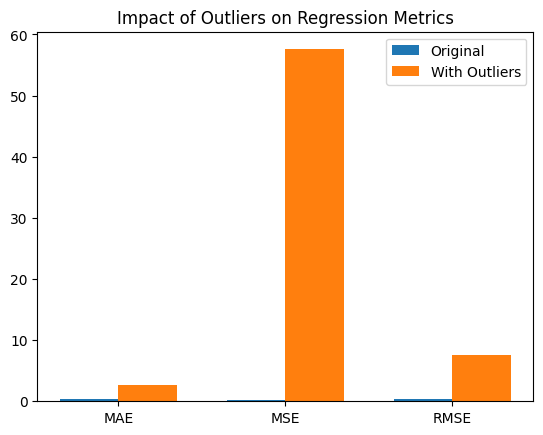

In [ ]:
metrics_names = ["MAE", "MSE", "RMSE"]

original_values = [mae_original, mse_original, rmse_original]
outlier_values = [mae_outlier, mse_outlier, rmse_outlier]

x = np.arange(len(metrics_names))
width = 0.35

plt.figure()
plt.bar(x - width/2, original_values, width, label="Original")
plt.bar(x + width/2, outlier_values, width, label="With Outliers")

plt.xticks(x, metrics_names)
plt.title("Impact of Outliers on Regression Metrics")
plt.legend()
plt.show()

Classification

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve

In [ ]:
X_clf = df.drop(columns=['class'])
y_clf = df['class']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf_model = LogisticRegression(max_iter = 5000)
clf_model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [ ]:
y_pred = clf_model.predict(X_test)
y_prob = clf_model.predict_proba(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision (macro):", precision_score(y_test, y_pred, average='macro'))
print("Recall (macro):", recall_score(y_test, y_pred, average='macro'))
print("F1 Score (macro):", f1_score(y_test, y_pred, average='macro'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9814814814814815
Precision (macro): 0.9777777777777779
Recall (macro): 0.9841269841269842
F1 Score (macro): 0.9803756658256239
Confusion Matrix:
 [[19  0  0]
 [ 0 20  1]
 [ 0  0 14]]


ROC AUC Score (OvR): 0.9995189995189996



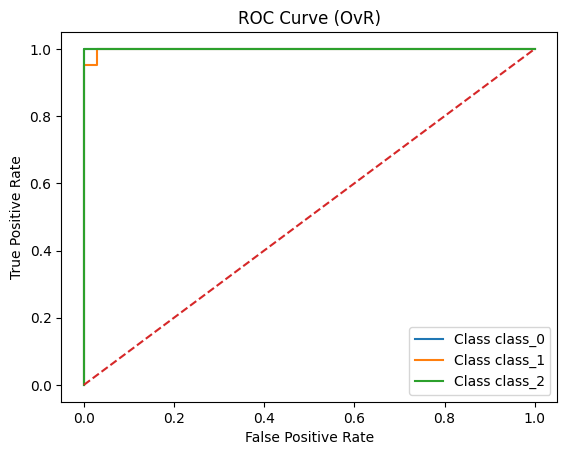

In [ ]:
y_test_bin = label_binarize(y_test, classes=[0,1,2])

roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr')
print("ROC AUC Score (OvR):", roc_auc)
print("")

plt.figure()
class_names = wine.target_names
for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f'Class {class_names[i]}')

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (OvR)')
plt.legend()
plt.show()

Clustering

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score)

In [ ]:
X_cluster = df.drop(columns=['class'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42)
y_pred_cluter = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, y_pred_cluter)
db = davies_bouldin_score(X_scaled, y_pred_cluter)
ch = calinski_harabasz_score(X_scaled, y_pred_cluter)
ari = adjusted_rand_score(y, y_pred_cluter)

print("Silhouette Score:", sil)
print("Davies-Bouldin Score:", db)
print("Calinski-Harabasz Score:", ch)
print("Adjusted Rand Score:", ari)

Silhouette Score: 0.2848589191898987
Davies-Bouldin Score: 1.3891879777181646
Calinski-Harabasz Score: 70.9400080031512
Adjusted Rand Score: 0.8974949815093207
